## Importing Libraries and Datasets

In [75]:
!pip install pandas scikit-learn
import pandas as pd 
import numpy as np

In [76]:
df = pd.read_csv("Text_Processed_Dataset.csv")
df.shape

(5169, 6)

In [77]:
df.head(3)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...


------

## Text Vectorization

In [78]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features=3000)

In [79]:

df.dropna(subset=['transformed_text'], inplace=True)


df['transformed_text'] = df['transformed_text'].fillna('')


X = tf.fit_transform(df['transformed_text']).toarray()

In [80]:
X.shape

(5160, 3000)

In [81]:
y = df['target'].values

----

## Train Test Split

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

-----

## Naive Bayes Model Trainng

In [84]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

**GaussianNB**

In [85]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.875
[[798 108]
 [ 21 105]]
0.49295774647887325


**MultinomialNB**

In [86]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9748062015503876
[[906   0]
 [ 26 100]]
1.0


**BernoulliNB**

In [87]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9844961240310077
[[904   2]
 [ 14 112]]
0.9824561403508771


-------

## Other Machine Learning Model

In [88]:
!pip install xgboost

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [90]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [91]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [92]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [93]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9738372093023255
Precision -  0.9805825242718447
For  KN
Accuracy -  0.9224806201550387
Precision -  1.0
For  NB
Accuracy -  0.9748062015503876
Precision -  1.0
For  DT
Accuracy -  0.936046511627907
Precision -  0.7830188679245284
For  LR
Accuracy -  0.9602713178294574
Precision -  0.9473684210526315


/Users/Aniashfiee/Documents/Email-SMS-Classifier/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/Aniashfiee/Documents/Email-SMS-Classifier/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9699612403100775
Precision -  0.9702970297029703
For  AdaBoost
Accuracy -  0.9224806201550387
Precision -  0.7948717948717948
For  BgC
Accuracy -  0.9525193798449613
Precision -  0.8181818181818182
For  ETC
Accuracy -  0.9728682170542635
Precision -  0.99
For  GBDT
Accuracy -  0.9554263565891473
Precision -  0.9166666666666666
For  xgb
Accuracy -  0.9709302325581395
Precision -  0.9444444444444444


In [94]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.922481,1.000000
2,NB,0.974806,1.000000
8,ETC,0.972868,0.990000
0,SVC,0.973837,0.980583
5,RF,0.969961,0.970297
4,LR,0.960271,0.947368
10,xgb,0.970930,0.944444
9,GBDT,0.955426,0.916667
7,BgC,0.952519,0.818182
6,AdaBoost,0.922481,0.794872


In [95]:
performance_df = pd.melt(performance_df, id_vars = "Algorithm")
performance_df

,Algorithm,variable,value
0,KN,Accuracy,0.922481
1,NB,Accuracy,0.974806
2,ETC,Accuracy,0.972868
3,SVC,Accuracy,0.973837
4,RF,Accuracy,0.969961
5,LR,Accuracy,0.960271
6,xgb,Accuracy,0.970930
7,GBDT,Accuracy,0.955426
8,BgC,Accuracy,0.952519
9,AdaBoost,Accuracy,0.922481


In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

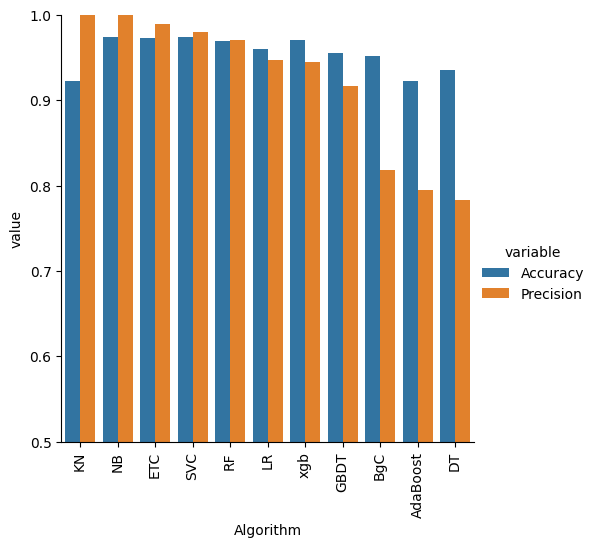

In [97]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

------

## Model Improvement

In [98]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [99]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [100]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,variable,value,Accuracy_max_ft_3000_x,Precision_max_ft_3000_x,Accuracy_max_ft_3000_y,Precision_max_ft_3000_y,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,Accuracy,0.922481,0.922481,1.000000,0.922481,1.000000,0.922481,1.000000
1,NB,Accuracy,0.974806,0.974806,1.000000,0.974806,1.000000,0.974806,1.000000
2,ETC,Accuracy,0.972868,0.972868,0.990000,0.972868,0.990000,0.972868,0.990000
3,SVC,Accuracy,0.973837,0.973837,0.980583,0.973837,0.980583,0.973837,0.980583
4,RF,Accuracy,0.969961,0.969961,0.970297,0.969961,0.970297,0.969961,0.970297
5,LR,Accuracy,0.960271,0.960271,0.947368,0.960271,0.947368,0.960271,0.947368
6,xgb,Accuracy,0.970930,0.970930,0.944444,0.970930,0.944444,0.970930,0.944444
7,GBDT,Accuracy,0.955426,0.955426,0.916667,0.955426,0.916667,0.955426,0.916667
8,BgC,Accuracy,0.952519,0.952519,0.818182,0.952519,0.818182,0.952519,0.818182
9,AdaBoost,Accuracy,0.922481,0.922481,0.794872,0.922481,0.794872,0.922481,0.794872


-------

## Saving The best fitted model mnb

In [101]:
import pickle

In [102]:
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))